In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

In [2]:
df = pd.read_csv('stock_market_impact_energy_sector.csv')

In [3]:
df.head()

,Date,Stock_Symbol,Opening_Price,Closing_Price,Percent_Change,Trading_Volume,Sector
0,2026-04-01,XOM (Exxon),135.95,134.32,-1.20,54032796.0,Energy
1,2026-04-02,XOM (Exxon),135.95,135.96,0.01,52291801.0,Energy
2,2026-04-03,XOM (Exxon),135.95,137.61,1.22,24776548.0,Energy
3,2026-04-04,XOM (Exxon),135.95,139.26,2.44,54428583.0,Energy
4,2026-04-05,XOM (Exxon),135.95,140.91,3.65,38842774.0,Energy


In [4]:
df.tail()

,Date,Stock_Symbol,Opening_Price,Closing_Price,Percent_Change,Trading_Volume,Sector
43,2026-04-04,VTI (Total Market),95.71,94.53,-1.24,66826786.0,Broad Market
44,2026-04-05,VTI (Total Market),95.71,94.23,-1.55,61268649.0,Broad Market
45,2026-04-06,VTI (Total Market),95.71,93.93,-1.86,41897835.0,Broad Market
46,2026-04-07,VTI (Total Market),95.71,93.63,-2.17,62601990.0,Broad Market
47,2026-04-08,VTI (Total Market),95.71,93.33,-2.49,50831542.0,Broad Market


In [5]:
df.columns

Index(['Date', 'Stock_Symbol', 'Opening_Price', 'Closing_Price',
       'Percent_Change', 'Trading_Volume', 'Sector'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            48 non-null     object 
 1   Stock_Symbol    48 non-null     object 
 2   Opening_Price   48 non-null     float64
 3   Closing_Price   48 non-null     float64
 4   Percent_Change  48 non-null     float64
 5   Trading_Volume  48 non-null     float64
 6   Sector          48 non-null     object 
dtypes: float64(4), object(3)
memory usage: 2.8+ KB


In [7]:
df.isnull().sum()

Date              0
Stock_Symbol      0
Opening_Price     0
Closing_Price     0
Percent_Change    0
Trading_Volume    0
Sector            0
dtype: int64

In [8]:
df.dtypes

Date               object
Stock_Symbol       object
Opening_Price     float64
Closing_Price     float64
Percent_Change    float64
Trading_Volume    float64
Sector             object
dtype: object

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df.describe()

,Date,Opening_Price,Closing_Price,Percent_Change,Trading_Volume
count,48,48.000000,48.000000,48.000000,4.800000e+01
mean,2026-04-04 12:00:00,102.081667,103.864792,1.509792,5.182174e+07
min,2026-04-01 00:00:00,76.380000,74.190000,-2.860000,2.109482e+07
25%,2026-04-02 18:00:00,80.310000,83.082500,-1.185000,4.293404e+07
50%,2026-04-04 12:00:00,101.130000,100.555000,1.175000,5.331463e+07
75%,2026-04-06 06:00:00,117.590000,120.890000,3.900000,6.099539e+07
max,2026-04-08 00:00:00,135.950000,145.850000,7.780000,7.971264e+07
std,NaN,20.966915,22.739994,3.049581,1.324545e+07


In [11]:
df['Stock_Symbol'].unique()

array(['XOM (Exxon)', 'CVX (Chevron)', 'RDSA (Shell)', 'MPC (Marathon)',
       'SPLG (S&P 500)', 'VTI (Total Market)'], dtype=object)

In [12]:
df['Sector'].value_counts()

Sector
Energy          32
Broad Market    16
Name: count, dtype: int64

In [13]:
df['Opening_Price'].describe()

count     48.000000
mean     102.081667
std       20.966915
min       76.380000
25%       80.310000
50%      101.130000
75%      117.590000
max      135.950000
Name: Opening_Price, dtype: float64

In [14]:
df['Opening_Price'].nunique()

6

In [15]:
df.drop(columns=['Percent_Change'], inplace=True)

In [16]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

In [17]:
df.head()

,Date,Stock_Symbol,Opening_Price,Closing_Price,Trading_Volume,Sector,Year,Month,Day,DayOfWeek
0,2026-04-01,XOM (Exxon),135.95,134.32,54032796.0,Energy,2026,4,1,2
1,2026-04-02,XOM (Exxon),135.95,135.96,52291801.0,Energy,2026,4,2,3
2,2026-04-03,XOM (Exxon),135.95,137.61,24776548.0,Energy,2026,4,3,4
3,2026-04-04,XOM (Exxon),135.95,139.26,54428583.0,Energy,2026,4,4,5
4,2026-04-05,XOM (Exxon),135.95,140.91,38842774.0,Energy,2026,4,5,6


In [18]:
df.drop(columns='Date', inplace=True)

In [19]:
df = pd.get_dummies(df, columns=['Stock_Symbol'], drop_first=True)

In [20]:
df.head()

,Opening_Price,Closing_Price,Trading_Volume,Sector,Year,Month,Day,DayOfWeek,Stock_Symbol_MPC (Marathon),Stock_Symbol_RDSA (Shell),Stock_Symbol_SPLG (S&P 500),Stock_Symbol_VTI (Total Market),Stock_Symbol_XOM (Exxon)
0,135.95,134.32,54032796.0,Energy,2026,4,1,2,False,False,False,False,True
1,135.95,135.96,52291801.0,Energy,2026,4,2,3,False,False,False,False,True
2,135.95,137.61,24776548.0,Energy,2026,4,3,4,False,False,False,False,True
3,135.95,139.26,54428583.0,Energy,2026,4,4,5,False,False,False,False,True
4,135.95,140.91,38842774.0,Energy,2026,4,5,6,False,False,False,False,True


In [21]:
df = pd.get_dummies(df, columns=['Sector'], drop_first=True)

In [22]:
y = df['Closing_Price']


In [23]:
X = df.drop(columns='Closing_Price')

In [24]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [25]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

In [26]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [27]:
predictions = model.predict(X_test)
print(predictions)

[76.42455  77.375336 80.82384  81.32065  81.94168  82.57886  83.24372
 82.52966  84.55505  85.1479  ]


In [28]:
mae = mean_absolute_error(y_test, predictions)
print(mae)

9.803852355957032


In [29]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(rmse)

10.613299388631546


In [30]:
r2 = r2_score(y_test, predictions)
print(r2)

-0.7397454705339992


In [31]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

Opening_Price                      0.996118
Day                                0.003687
Trading_Volume                     0.000175
DayOfWeek                          0.000020
Month                              0.000000
Year                               0.000000
Stock_Symbol_MPC (Marathon)        0.000000
Stock_Symbol_RDSA (Shell)          0.000000
Stock_Symbol_SPLG (S&P 500)        0.000000
Stock_Symbol_VTI (Total Market)    0.000000
dtype: float32

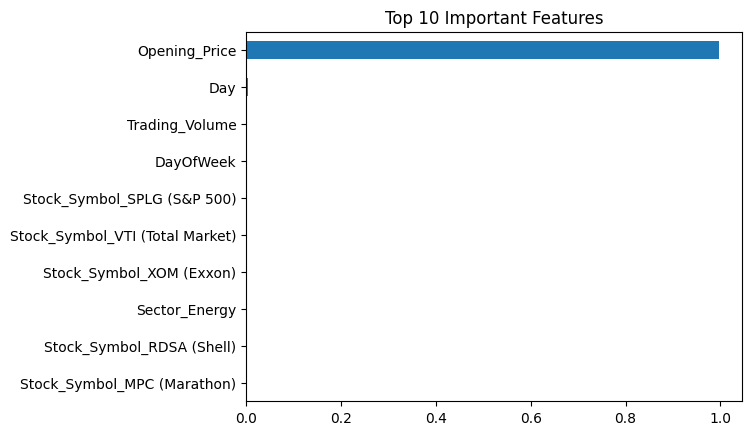

In [32]:
importance.sort_values().tail(10).plot(kind='barh')

plt.title("Top 10 Important Features")

plt.show()

In [33]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

results.head()

,Actual,Predicted
38,74.45,76.424553
39,74.19,77.375336
40,95.42,80.823837
41,95.12,81.320648
42,94.83,81.941681


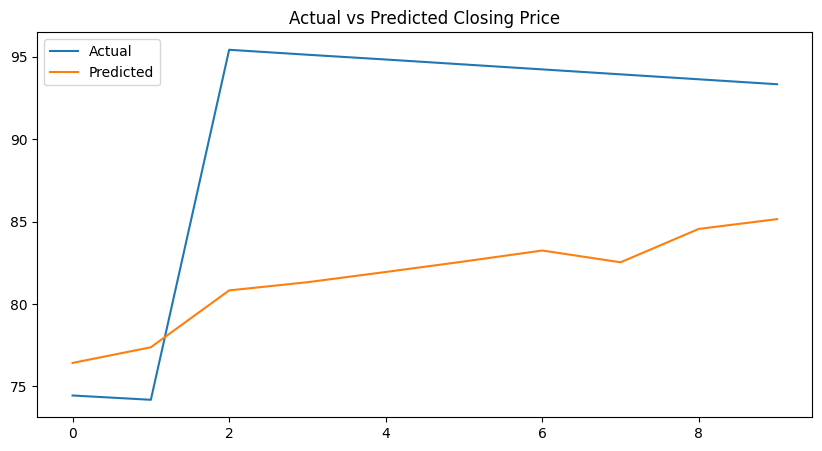

In [34]:
plt.figure(figsize=(10,5))

plt.plot(results['Actual'].values, label='Actual')
plt.plot(results['Predicted'].values, label='Predicted')

plt.legend()

plt.title("Actual vs Predicted Closing Price")

plt.show()

In [35]:
import joblib

joblib.dump(model, "xgboost_stock_model.pkl")

['xgboost_stock_model.pkl']

In [36]:
model = joblib.load("xgboost_stock_model.pkl")

In [38]:
df.groupby('Closing_Price')['Opening_Price'].mean().sort_values(ascending=False)

Closing_Price
145.85    135.95
144.21    135.95
142.56    135.95
140.91    135.95
139.26    135.95
137.61    135.95
135.96    135.95
134.32    135.95
126.73    117.59
125.18    117.59
123.62    117.59
122.06    117.59
120.50    117.59
118.94    117.59
117.39    117.59
115.83    117.59
105.69    106.55
106.76    106.55
107.82    106.55
108.89    106.55
109.95    106.55
111.02    106.55
112.09    106.55
113.15    106.55
93.33      95.71
93.63      95.71
93.93      95.71
94.23      95.71
94.53      95.71
94.83      95.71
95.12      95.71
95.42      95.71
80.71      80.31
81.35      80.31
81.98      80.31
82.61      80.31
83.24      80.31
83.88      80.31
84.51      80.31
85.14      80.31
74.19      76.38
74.45      76.38
74.71      76.38
74.97      76.38
75.23      76.38
75.48      76.38
75.74      76.38
76.00      76.38
Name: Opening_Price, dtype: float64

In [ ]:
df.groupby('Sector')['Closing_Price'].mean().sort_values(ascending=False)

Sector
Energy          113.428750
Broad Market     84.736875
Name: Closing_Price, dtype: float64

In [ ]:
df.groupby('Sector')['Opening_Price'].median().sort_values(ascending=False)

Sector
Energy          112.070
Broad Market     86.045
Name: Opening_Price, dtype: float64

In [ ]:
df.groupby('Percent_Change')['Opening_Price'].mean().sort_values(ascending=False)

Percent_Change
-1.20    135.95
 7.29    135.95
 6.07    135.95
 4.86    135.95
 2.44    135.95
 1.22    135.95
 0.01    135.95
-0.18    117.59
 1.15    117.59
-1.50    117.59
 2.47    117.59
 7.78    117.59
 6.45    117.59
 5.12    117.59
 3.80    117.59
 3.65    108.13
 5.20    106.55
 3.20    106.55
 4.20    106.55
 1.20    106.55
 6.20    106.55
-0.80    106.55
 0.20    106.55
 2.20    106.55
-2.17     95.71
-1.24     95.71
-1.55     95.71
-2.49     95.71
-1.86     95.71
-0.61     95.71
-0.93     95.71
-0.30     95.71
 4.44     80.31
 0.50     80.31
 2.08     80.31
 6.01     80.31
 2.86     80.31
 5.22     80.31
 1.29     80.31
-0.84     76.38
-1.18     76.38
-1.51     76.38
-1.85     76.38
-2.53     76.38
-2.86     76.38
-2.19     76.38
-0.50     76.38
Name: Opening_Price, dtype: float64

In [ ]:
df.groupby('Sector')['Opening_Price'].count().sort_values(ascending=False)

Sector
Energy          32
Broad Market    16
Name: Opening_Price, dtype: int64

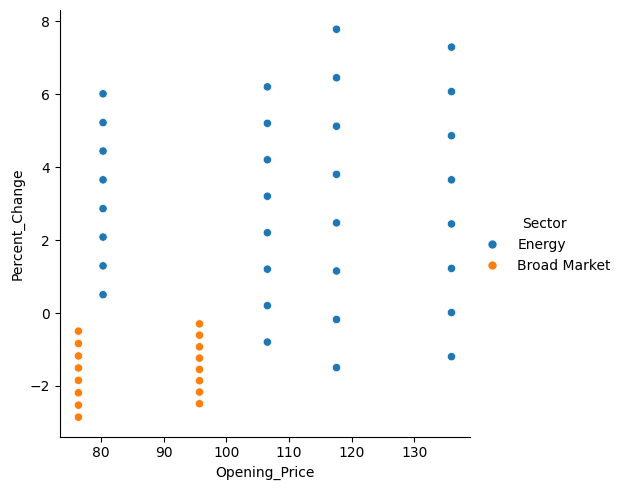

In [ ]:
sns.relplot(x='Opening_Price', y='Percent_Change', data=df, hue='Sector', kind='scatter')

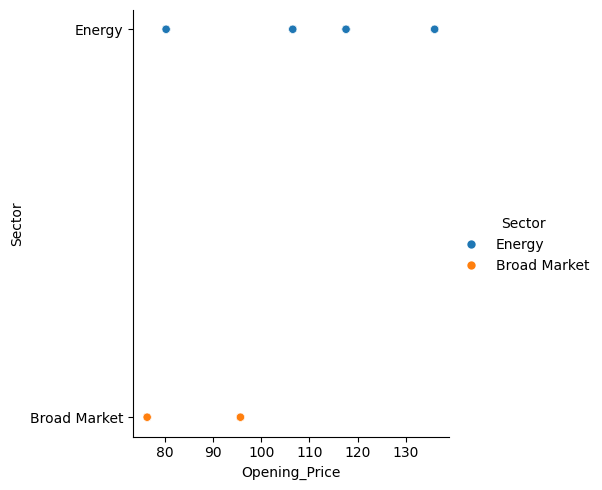

In [ ]:
sns.relplot(x='Opening_Price', y='Sector', data=df, hue='Sector', kind='scatter')

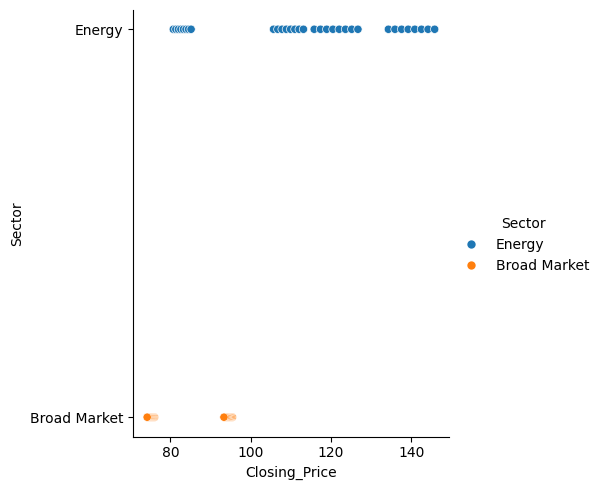

In [ ]:
sns.relplot(x='Closing_Price', y='Sector', data=df, hue='Sector', kind='scatter')